In [1]:
# Import

import os
import numpy as np
import librosa
import librosa.display
from sklearn.model_selection import train_test_split

In [2]:
# Define Dataset Path

BASE_PATH = "/kaggle/input/datasets/urvishp80/irmas-training-data/IRMAS-TrainingData"

file_paths = []
labels = []

for instrument in os.listdir(BASE_PATH):
    instrument_path = os.path.join(BASE_PATH, instrument)
    
    if os.path.isdir(instrument_path):
        for file in os.listdir(instrument_path):
            if file.endswith(".wav"):
                file_paths.append(os.path.join(instrument_path, file))
                labels.append(instrument)

print("Total files:", len(file_paths))

Total files: 6705


In [3]:
# Create Label Map

unique_labels = sorted(list(set(labels)))
label_map = {label: idx for idx, label in enumerate(unique_labels)}

print("Label Map:", label_map)

Label Map: {'cel': 0, 'cla': 1, 'flu': 2, 'gac': 3, 'gel': 4, 'org': 5, 'pia': 6, 'sax': 7, 'tru': 8, 'vio': 9, 'voi': 10}


In [4]:
# Augmentation Function (Training Only)

def augment_audio(audio, sr):
    
    # Random pitch shift
    if np.random.rand() < 0.5:
        audio = librosa.effects.pitch_shift(audio, sr=sr, n_steps=np.random.choice([-1, 1]))
    
    # Random noise
    if np.random.rand() < 0.5:
        noise = 0.003 * np.random.randn(len(audio))
        audio = audio + noise
    
    return audio

In [5]:
# Preprocessing Function

def preprocess_audio(file_path, augment=False):
    
    audio, sr = librosa.load(file_path, sr=16000)
    
    # Apply augmentation only if training
    if augment:
        audio = augment_audio(audio, sr)
    
    # Trim silence
    audio, _ = librosa.effects.trim(audio)
    
    # RMS normalize
    rms = np.sqrt(np.mean(audio**2))
    audio = audio * (0.1 / rms)
    
    # Mel spectrogram
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128
    )

    # Log Scaling
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    # Standardize
    mel_db = (mel_db - np.mean(mel_db)) / np.std(mel_db)
    
    # Resize to fixed shape
    fixed_length = 128
    
    if mel_db.shape[1] < fixed_length:
        pad_width = fixed_length - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode='constant')
    else:
        mel_db = mel_db[:, :fixed_length]
    
    return mel_db

In [6]:
# First Split File List (Before Processing)


X_train_files, X_temp_files, y_train_labels, y_temp_labels = train_test_split(
    file_paths,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

X_val_files, X_test_files, y_val_labels, y_test_labels = train_test_split(
    X_temp_files,
    y_temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=y_temp_labels
)

print("Train files:", len(X_train_files))
print("Validation files:", len(X_val_files))
print("Test files:", len(X_test_files))

Train files: 5364
Validation files: 670
Test files: 671


In [7]:
# Process Training Set (With Augmentation)

X_train = []
y_train = []

for file_path, label in zip(X_train_files, y_train_labels):
    mel = preprocess_audio(file_path, augment=True)
    X_train.append(mel)
    y_train.append(label_map[label])

print("Training processed")

Training processed


In [8]:
# Process Validation & Test (No Augmentation)

X_val = []
y_val = []

for file_path, label in zip(X_val_files, y_val_labels):
    mel = preprocess_audio(file_path, augment=False)
    X_val.append(mel)
    y_val.append(label_map[label])

print("Validation processed")


X_test = []
y_test = []

for file_path, label in zip(X_test_files, y_test_labels):
    mel = preprocess_audio(file_path, augment=False)
    X_test.append(mel)
    y_test.append(label_map[label])

print("Test processed")

Validation processed
Test processed


In [9]:
# Convert to NumPy

X_train = np.array(X_train)[..., np.newaxis]
X_val = np.array(X_val)[..., np.newaxis]
X_test = np.array(X_test)[..., np.newaxis]

y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (5364, 128, 128, 1)
Val shape: (670, 128, 128, 1)
Test shape: (671, 128, 128, 1)


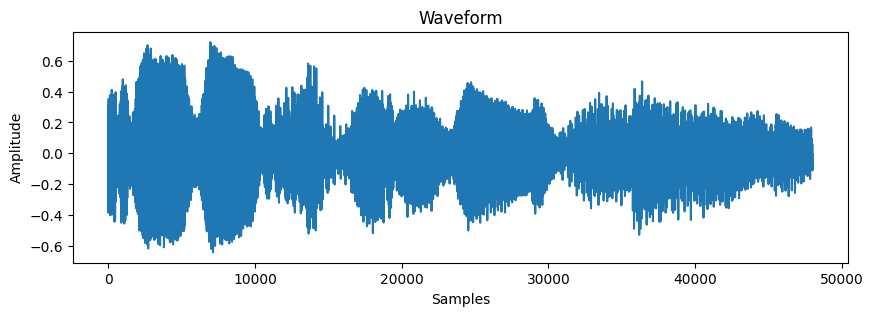

In [10]:
# Showing the webform of an audio file

import matplotlib.pyplot as plt

index = 30   # change this number (0, 1, 2, 50, 100...)
file_path = file_paths[index]

audio, sr = librosa.load(file_path, sr=16000)

plt.figure(figsize=(10,3))
plt.plot(audio)
plt.title("Waveform")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

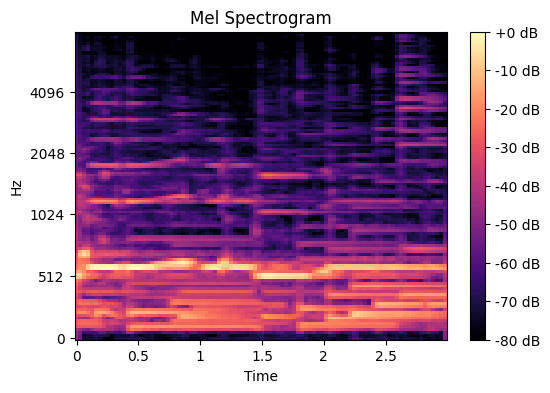

In [11]:
# Mel Spectrogram image of an audio

import librosa.display

mel = librosa.feature.melspectrogram(
    y=audio,
    sr=sr,
    n_mels=128
)

mel_db = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(6,4))
librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis='time',
    y_axis='mel'
)
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")
plt.show()

In [12]:
# Building CNN Model

import tensorflow as tf
from tensorflow.keras import layers, models


num_classes = len(label_map)

model = models.Sequential()

# 🔹 Layer 1
model.add(layers.Conv2D(16, (3,3), activation='relu', input_shape=(128,128,1)))
model.add(layers.MaxPooling2D((2,2)))

# 🔹 Layer 2
model.add(layers.Conv2D(32, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# 🔹 Layer 3
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# 🔹 Flatten
model.add(layers.Flatten())

# 🔹 Dense Layer
model.add(layers.Dense(128, activation='relu'))

# 🔹 Output Layer
model.add(layers.Dense(num_classes, activation='softmax'))


# See Model Summary
model.summary()

2026-02-25 14:55:40.284207: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772031340.533457      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772031340.600894      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772031341.141959      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772031341.142003      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772031341.142006      55 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,630,475 (6.22 MB)

 Trainable params: 1,630,475 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
# Train Model

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/15


I0000 00:00:1772031787.314647     154 service.cc:152] XLA service 0x7c1954006120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772031787.314717     154 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772031787.314724     154 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772031787.780077     154 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-25 15:03:09.618902: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 15:03:09.759196: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 18/168 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0958 - loss: 2.5932

I0000 00:00:1772031791.790516     154 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


162/168 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1543 - loss: 2.3585

2026-02-25 15:03:14.121117: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 15:03:14.260881: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


168/168 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.1575 - loss: 2.3518 - val_accuracy: 0.3090 - val_loss: 1.9829
Epoch 2/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3669 - loss: 1.8530 - val_accuracy: 0.3851 - val_loss: 1.9596
Epoch 3/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4556 - loss: 1.6151 - val_accuracy: 0.4343 - val_loss: 1.7740
Epoch 4/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5502 - loss: 1.3834 - val_accuracy: 0.4821 - val_loss: 1.7224
Epoch 5/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6389 - loss: 1.1067 - val_accuracy: 0.4910 - val_loss: 1.7056
Epoch 6/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7245 - loss: 0.8416 - val_accuracy: 0.4881 - val_loss: 1.8358
Epoch 7/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8313 - loss: 0.5518 - val_accuracy: 0.5194 - val_loss: 1.9201
Epoch 8/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8806 - loss: 0.3719 - val_accuracy: 0.50

In [15]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.4945 - loss: 3.7238
Test Accuracy: 0.4754098355770111
